# Lecture 04 — Supermarket basket associations

**Module:** OMC9000UK7 · Principles and Applications of Artificial Intelligence and Machine Learning  
**Programme:** MSc AI and Machine Learning · Gulf College  
**Lecture:** 04 — Introduction to Machine Learning and Data Mining  
**Topic:** Association rule mining · **Learning outcome emphasis:** MLO1 and MLO3 (with MLO4 preparation through technique selection)

## Learning objective
Calculate support, confidence and lift without an additional mining library.

## Practical problem
Find co-purchase patterns and give a transparent, rule-based product suggestion.

## Dataset and transparency
The file **`dataset.csv`** was simulated for teaching. It is not collected from real people, businesses, medical systems or physical devices. Names/values are illustrative; models must not be deployed or used for real eligibility, employment, financial, clinical or safety decisions. A fixed random seed makes the example reproducible.

**How to run:** keep this notebook and `dataset.csv` in the same folder, then run all cells from top to bottom. If needed, install the packages listed in the collection’s `requirements.txt`.

**Assumptions:** Transactions were generated from simplified shopping preferences; correlation is not a purchasing cause.

## 1. Load the dataset and understand the variables
Always inspect several rows, column names, types, and possible missing values before choosing a model.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (7.2, 4.5), 'axes.grid': True, 'grid.alpha': .22})
DATA_FILE = Path('dataset.csv')
assert DATA_FILE.exists(), 'Place dataset.csv next to the notebook.'
df = pd.read_csv(DATA_FILE)
print(f'Dataset: {len(df):,} rows × {df.shape[1]} columns')
display(df.head())

Dataset: 650 rows × 9 columns


,bread,milk,butter,jam,eggs,tea,coffee,rice,transaction_id
0,1,1,1,0,1,0,0,0,1
1,0,0,0,0,0,0,0,1,2
2,0,1,0,0,0,1,1,0,3
3,1,1,0,0,0,0,1,0,4
4,0,0,0,1,0,0,0,0,5


In [2]:
print('Columns:', df.columns.tolist())
print('Missing values per column:')
print(df.isna().sum().to_string())

Columns: ['bread', 'milk', 'butter', 'jam', 'eggs', 'tea', 'coffee', 'rice', 'transaction_id']
Missing values per column:
bread             0
milk              0
butter            0
jam               0
eggs              0
tea               0
coffee            0
rice              0
transaction_id    0


## 2. Visualise purchase patterns
Transactions are represented by zeros and ones: 1 means the item was observed in the basket. No product is a supervised class label.

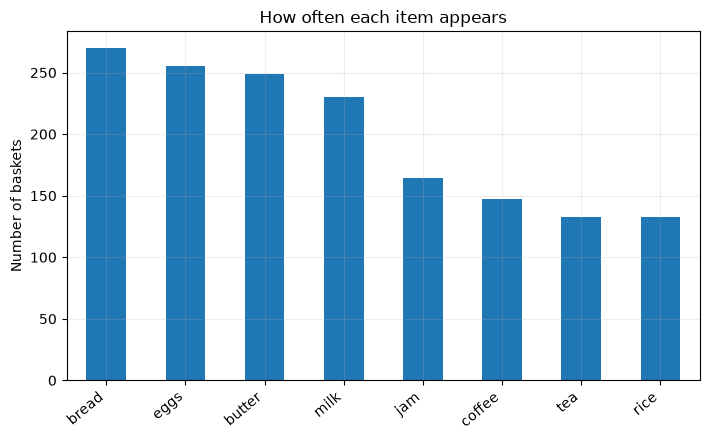

Example baskets:
1 ['bread', 'milk', 'butter', 'eggs']
2 ['rice']
3 ['milk', 'tea', 'coffee']
4 ['bread', 'milk', 'coffee']
5 ['jam']


In [3]:
items=[c for c in df.columns if c!='transaction_id']
counts=df[items].sum().sort_values(ascending=False)
counts.plot.bar(title='How often each item appears',ylabel='Number of baskets');plt.xticks(rotation=40,ha='right');plt.tight_layout();plt.show()
print('Example baskets:')
for _,r in df.head(5).iterrows():
 print(int(r['transaction_id']),[i for i in items if r[i]==1])

## 3. Derive association rules (one antecedent item → one consequent item)
**Support** = proportion of all baskets containing both items. **Confidence** = proportion containing B among baskets containing A. **Lift** = confidence divided by the overall frequency of B; lift above 1 indicates positive association. Association rules are descriptive; they do not prove causation.

In [4]:
from itertools import permutations
items=[c for c in df.columns if c!='transaction_id']
N=len(df)
# Simple pedagogical implementation of one-item => one-item association rules.
rows=[]
for left,right in permutations(items,2):
    pa=df[left].mean();pb=df[right].mean()
    pab=((df[left]==1)&(df[right]==1)).mean()
    if pa==0 or pb==0: continue
    confidence=pab/pa
    lift=confidence/pb
    rows.append({'if_bought':left,'then_recommend':right,'support':pab,'confidence':confidence,'lift':lift})
rules=pd.DataFrame(rows)
strong=rules.query('support >= .10 and confidence >= .30').sort_values(['lift','confidence'],ascending=False)
print(f'{len(strong)} filtered rules from {N} orders')
display(strong.head(12).round(3))

19 filtered rules from 650 orders


,if_bought,then_recommend,support,confidence,lift
23,jam,butter,0.146,0.579,1.512
16,butter,jam,0.146,0.382,1.512
36,tea,milk,0.102,0.496,1.402
43,coffee,milk,0.111,0.490,1.384
12,milk,coffee,0.111,0.313,1.384
51,rice,butter,0.108,0.526,1.374
21,jam,bread,0.142,0.561,1.350
2,bread,jam,0.142,0.341,1.350
53,rice,eggs,0.106,0.519,1.322
28,eggs,bread,0.180,0.459,1.105


## 4. Plot the discovered rules
A strong rule should have useful support as well as lift: an apparently enormous lift from a very rare combination may not generalise.

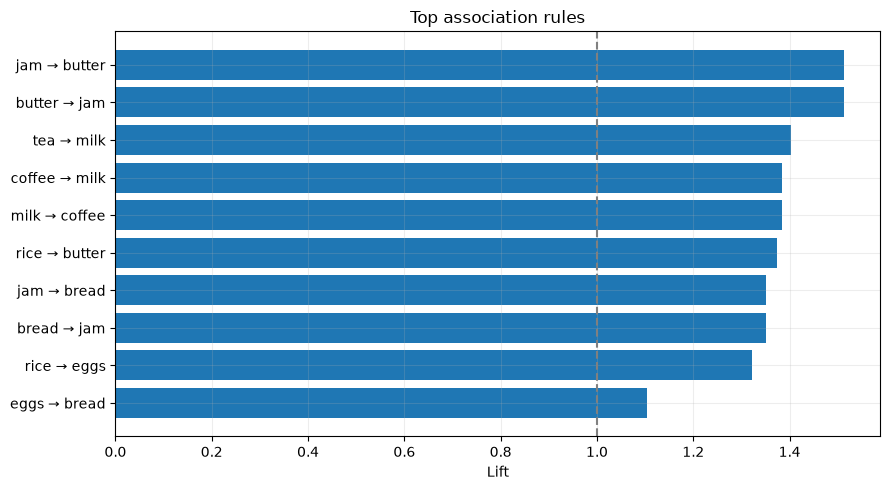

In [5]:
top=strong.head(10).copy()
if top.empty: top=rules.sort_values('lift',ascending=False).head(10)
top['rule']=top['if_bought']+' → '+top['then_recommend']
fig,ax=plt.subplots(figsize=(9,5))
ax.barh(top['rule'].iloc[::-1],top['lift'].iloc[::-1]);ax.axvline(1,linestyle='--',color='gray')
ax.set(xlabel='Lift',title='Top association rules');plt.tight_layout();plt.show()

## 5. Make a rule-based suggestion for a new basket
This is an association-rule recommender: the recommendation is the consequent of the strongest matching rule, not a trained classification label. Consumers have different needs; co-purchases are not necessarily preferences.

In [6]:
cart=['bread']
options=strong[(strong['if_bought'].isin(cart)) & (~strong['then_recommend'].isin(cart))].copy()
print('Current basket:',cart)
if len(options):
 best=options.iloc[0]
 print(f"Suggested item: {best['then_recommend']} (confidence={best['confidence']:.1%}, lift={best['lift']:.2f})")
else: print('No suitable rule at the chosen support/confidence threshold.')

Current basket: ['bread']
Suggested item: jam (confidence=34.1%, lift=1.35)


## 6. Evaluation appropriate to association rules
Report **support, confidence, and lift**, and optionally validate held-out baskets. **Accuracy, precision, recall and confusion matrices** are not the general measures for an unsupervised association-rule discovery task; they would require defining a separate prediction target and evaluation protocol.

## Student investigation and discussion
1. Why is bread → butter different from butter → bread?
2. Why is lift a useful improvement over confidence alone?
3. Can a rule with lift >1 still be unusable if support is tiny?

**Reflect:** What assumption makes this classroom dataset easier than the equivalent real-world problem?

## References and further learning
- Russell, S. J., & Norvig, P. (2021). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.
- Mitchell, T. M. (1997). *Machine Learning*. McGraw-Hill.
- scikit-learn User Guide: https://scikit-learn.org/stable/user_guide.html
- Course connection: Lecture 04, OMC9000UK7, supervised/unsupervised learning, modelling workflow and evaluation.